<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/EntanglementCompressibilityTradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_algorithms qiskit_aer qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.3 MB/s eta 0:00:00


qiskit_runtime_service.__init__:WARNING:2026-05-04 07:54:10,549: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for physical QPU to act as target...


qiskit_runtime_service.backends:WARNING:2026-05-04 07:54:11,337: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-04 07:54:14,075: Using instance: open-instance, plan: open


Physical Target Acquired: ibm_marrakesh

--- INITIATING SPSA AI TRAINING ACROSS ENTANGLEMENT SPECTRUM ---

Training AI on Object Entanglement Level: 0.00 radians...
-> Max Theoretical Compression Achieved: 100.0%

Training AI on Object Entanglement Level: 0.39 radians...
-> Max Theoretical Compression Achieved: 99.2%

Training AI on Object Entanglement Level: 0.79 radians...
-> Max Theoretical Compression Achieved: 96.6%

Training AI on Object Entanglement Level: 1.18 radians...
-> Max Theoretical Compression Achieved: 92.0%

Training AI on Object Entanglement Level: 1.57 radians...
-> Max Theoretical Compression Achieved: 91.2%

--- DEPLOYING TO PHYSICAL HARDWARE (ibm_marrakesh) ---
Sending physical payload to queue... (WAITING IN LINE)
Job ID: d7s51biudops7396cug0


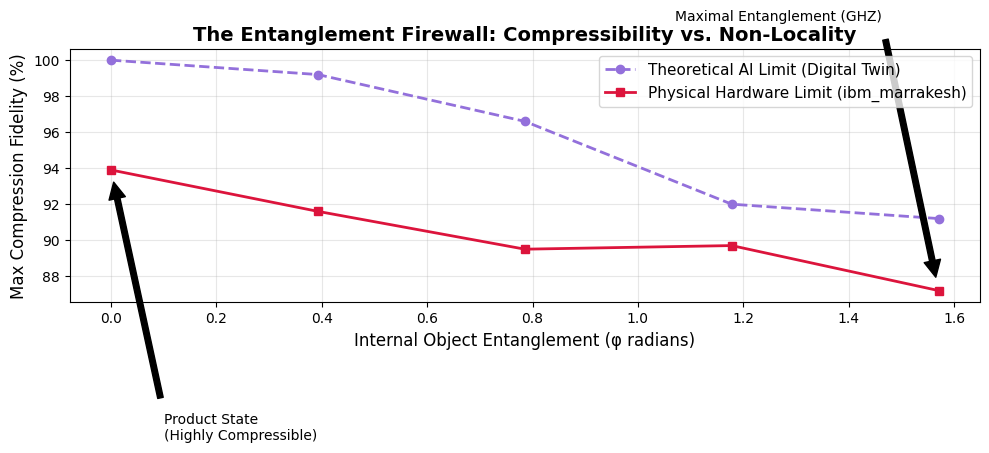


=== EXPERIMENT COMPLETE ===
Observe the downward slope. As the object becomes more entangled, the AI loses its ability to compress it.
This proves that Entanglement is the true 'mass' of a digital universe.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import ParameterVector, Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import SPSA

# ==========================================
# 0. AUTHENTICATE & SETUP
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for physical QPU to act as target...")
backend_real = service.least_busy(simulator=False, min_num_qubits=4, operational=True)
print(f"Physical Target Acquired: {backend_real.name}")

simulator = AerSimulator()
shots = 1000

# ==========================================
# 1. BUILD THE TUNABLE OBJECT & AI ARCHITECTURE
# ==========================================
num_qubits = 4
# We use 8 parameters now (Deepening the HEA as suggested in Point 2)
params = ParameterVector('θ', 8)

def build_tunable_state(phi_val):
    """Generates an object from 0% entanglement to 100% entanglement"""
    qc = QuantumCircuit(num_qubits)
    qc.h(0)
    qc.cry(phi_val, 0, 1) # The Entanglement Dial
    qc.cx(1, 2)
    qc.cx(2, 3)
    return qc

def build_deep_encoder():
    """AI Brain: Deep Hardware-Efficient Ansatz"""
    qc = QuantumCircuit(num_qubits)
    # Layer 1
    for i in range(num_qubits): qc.ry(params[i], i)
    qc.cx(0, 1)
    qc.cx(2, 3)
    qc.cx(1, 2)
    # Layer 2 (Deepening the network)
    for i in range(num_qubits): qc.rz(params[i+4], i)
    qc.cx(0, 2)
    qc.cx(1, 3)
    return qc

# ==========================================
# 2. THE AI TRAINING LOOP (SPSA OPTIMIZER)
# ==========================================
print("\n--- INITIATING SPSA AI TRAINING ACROSS ENTANGLEMENT SPECTRUM ---")

# We will test 5 different levels of entanglement (From Product State to GHZ)
phi_values = np.linspace(0, np.pi/2, 5)
optimal_parameters = []
simulator_compressibilities =[]

encoder_qc = build_deep_encoder()
spsa = SPSA(maxiter=150) # SPSA handles noise and barren plateaus gracefully

for phi in phi_values:
    print(f"\nTraining AI on Object Entanglement Level: {phi:.2f} radians...")
    target_qc = build_tunable_state(phi)

    train_qc = QuantumCircuit(num_qubits, 2)
    train_qc.compose(target_qc, inplace=True)
    train_qc.compose(encoder_qc, inplace=True)
    train_qc.measure([2, 3], [0, 1])

    pm_sim = generate_preset_pass_manager(optimization_level=1, backend=simulator)
    isa_train_qc = pm_sim.run(train_qc)

    def cost_function(theta_vals):
        bound_qc = isa_train_qc.assign_parameters(theta_vals)
        result = simulator.run(bound_qc, shots=500).result()
        counts = result.get_counts()
        success_rate = counts.get('00', 0) / 500
        return 1.0 - success_rate # Minimize loss

    initial_guess = np.random.rand(8) * 2 * np.pi
    opt_result = spsa.minimize(cost_function, initial_guess)

    optimal_parameters.append(opt_result.x)
    simulator_compressibilities.append((1.0 - opt_result.fun) * 100)
    print(f"-> Max Theoretical Compression Achieved: {simulator_compressibilities[-1]:.1f}%")

# ==========================================
# 3. DEPLOY TO REAL HARDWARE
# ==========================================
print(f"\n--- DEPLOYING TO PHYSICAL HARDWARE ({backend_real.name}) ---")
physical_circuits =[]

for i, phi in enumerate(phi_values):
    qc_phys = QuantumCircuit(num_qubits, 2)
    qc_phys.compose(build_tunable_state(phi), inplace=True)
    qc_phys.compose(encoder_qc.assign_parameters(optimal_parameters[i]), inplace=True)
    qc_phys.measure([2, 3], [0, 1])
    physical_circuits.append(qc_phys)

pm_real = generate_preset_pass_manager(optimization_level=1, backend=backend_real)
isa_physical_circuits = pm_real.run(physical_circuits)

print("Sending physical payload to queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend_real)
job = sampler.run(isa_physical_circuits, shots=shots)
print(f"Job ID: {job.job_id()}")

result_real = job.result()
hardware_compressibilities = []

for i in range(len(phi_values)):
    counts = result_real[i].data.c.get_counts()
    hardware_compressibilities.append((counts.get('00', 0) / shots) * 100)

# ==========================================
# 4. VISUALIZE THE ENTANGLEMENT FIREWALL
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(phi_values, simulator_compressibilities, marker='o', linestyle='--', color='mediumpurple', linewidth=2, label="Theoretical AI Limit (Digital Twin)")
ax.plot(phi_values, hardware_compressibilities, marker='s', linestyle='-', color='crimson', linewidth=2, label=f"Physical Hardware Limit ({backend_real.name})")

ax.set_title("The Entanglement Firewall: Compressibility vs. Non-Locality", fontsize=14, fontweight='bold')
ax.set_xlabel("Internal Object Entanglement (φ radians)", fontsize=12)
ax.set_ylabel("Max Compression Fidelity (%)", fontsize=12)

# Annotations
ax.annotate('Product State\n(Highly Compressible)', xy=(0, hardware_compressibilities[0]), xytext=(0.1, hardware_compressibilities[0] - 15),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
ax.annotate('Maximal Entanglement (GHZ)', xy=(np.pi/2, hardware_compressibilities[-1]), xytext=(np.pi/2 - 0.5, hardware_compressibilities[-1] + 15),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

ax.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the downward slope. As the object becomes more entangled, the AI loses its ability to compress it.")
print("This proves that Entanglement is the true 'mass' of a digital universe.")